# Coastal water levels

NOAA's Center for Operational Oceanographic Products and Services (CO-OPS)
runs the National Water Level Observation Network, about 200 long-term tide
stations on U.S. coasts and the Great Lakes. Each station reports its water
level every six minutes, and the CO-OPS Data API serves those observations,
preliminary at first and verified about a month later. One request returns one
CSV for one station, one vertical datum, and at most 28 days.

This walkthrough pulls three days of six-minute observations at The Battery,
at the southern tip of Manhattan, from 6 to 8 May 2024. It needs
`usdata[pandas]` and matplotlib, and downloads one 28 kB file in a second or
two.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-24T05:56:24+00:00
usdata 0.26.0; pandas 3.0.6


## Select

The manifest names one station by its seven-digit ID (`8518750` is The
Battery), the vertical datum the heights are measured from, the units, and a
window. `MLLW` is mean lower low water, the station's average of each day's
lower low tide over the 1983 to 2001 National Tidal Datum Epoch, so a height
of zero is an ordinary low tide and negative heights are lower than usual. A
different datum moves every value by a constant; it does not change the
shape of the curve. `units: metric` asks for metres.

Both bounds are inclusive and in UTC. A bare date as the end means 23:59 on
that day, so these two dates select three whole days: 720 six-minute
readings.

In [2]:
print(manifest.read_text())

name: coastal-water-levels
sources:
  - dataset: noaa:coops-water-levels
    start: 2024-05-06
    end: 2024-05-08
    params:
      station: "8518750"
      datum: MLLW
      units: metric



## What arrives

The first pull downloads one CSV and writes `dataset.lock.json` beside the
manifest, pinning the file's checksum. The source URL is the only place the
request's station, datum, units, and time zone are recorded.

In [3]:
result = pull(manifest)
(item,) = result.fetched
print("File:", item.path.name)
print("Bytes:", item.provenance.size)
print("Source:", item.provenance.source_url)
print("Retrieved (UTC):", item.provenance.retrieved_at.isoformat(timespec="seconds"))
print("Checksum:", item.provenance.checksum)

File: water_level_8518750_7559e70250be8e23.csv
Bytes: 27986
Source: https://api.tidesandcurrents.noaa.gov/api/prod/datagetter?station=8518750&product=water_level&begin_date=20240506+00%3A00&end_date=20240508+23%3A59&datum=MLLW&units=metric&time_zone=gmt&format=csv&application=usdata
Retrieved (UTC): 2026-09-24T05:56:24+00:00
Checksum: sha256:64799305cdaa292ed8272dfa9a9477702382cd412d2eff153c65160e934f108b


## Open

The generic CSV reader returns a DataFrame with NOAA's column names as
written, leading spaces included (`" Water Level"`, `" Quality "`). Stripping
them locally makes the columns easier to use and does not touch the cached
bytes. `Date Time` is text in UTC with no offset, because the request fixes
`time_zone=gmt`; parsing it with `utc=True` makes that explicit.

`Water Level` is metres above MLLW and `Sigma` the standard deviation of the
one-second samples behind each six-minute value. `Quality` is `p` for
preliminary or `v` for verified, and the four flag columns mean different
things in each state: on verified data the first is `I`, set when NOAA
inferred the value, and on preliminary data it is `O`, a count of outlying
samples. `F`, `R`, and `L` are set when a value exceeded the flat, rate of
change, or expected height tolerance.

In [4]:
frame = item.open().rename(columns=str.strip)
frame["Date Time"] = pd.to_datetime(frame["Date Time"], utc=True)
flags = ["O or I (for verified)", "F", "R", "L"]
print(f"{len(frame)} rows, {frame['Date Time'].min()} to {frame['Date Time'].max()}")
print("Quality:", frame["Quality"].value_counts().to_dict())
print("Rows with each flag set:", frame[flags].sum().to_dict())
frame.head()

720 rows, 2024-05-06 00:00:00+00:00 to 2024-05-08 23:54:00+00:00
Quality: {'v': 720}
Rows with each flag set: {'O or I (for verified)': 0, 'F': 0, 'R': 0, 'L': 40}


,Date Time,Water Level,Sigma,O or I (for verified),F,R,L,Quality
0,2024-05-06 00:00:00+00:00,1.765,0.060,0,0,0,0,v
1,2024-05-06 00:06:00+00:00,1.730,0.040,0,0,0,0,v
2,2024-05-06 00:12:00+00:00,1.702,0.065,0,0,0,0,v
3,2024-05-06 00:18:00+00:00,1.677,0.065,0,0,0,0,v
4,2024-05-06 00:24:00+00:00,1.642,0.124,0,0,0,0,v


## A first look

Three days of water level against the datum, with the readings NOAA flagged as
beyond its expected height limit drawn in orange.

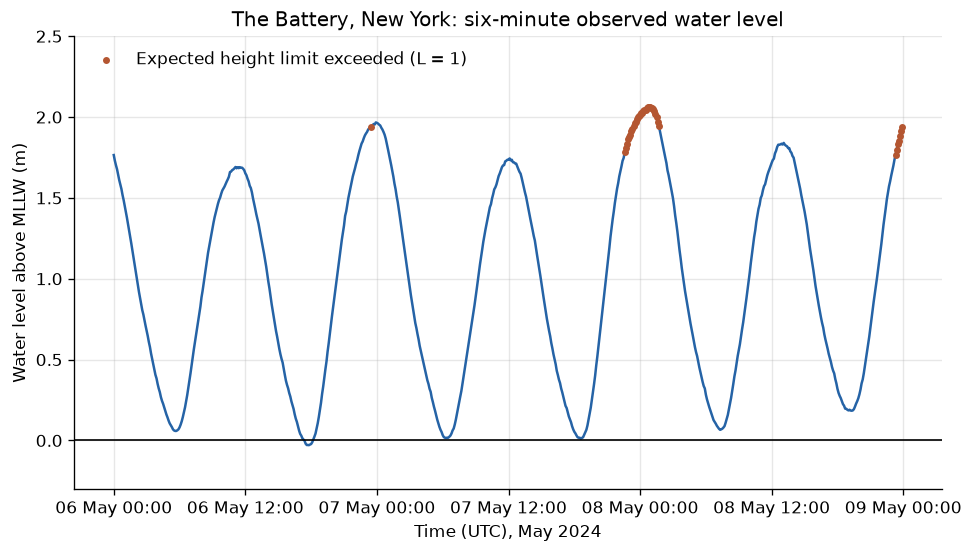

In [5]:
limit = frame["L"] == 1
fig, ax = plt.subplots(layout="constrained")
ax.plot(frame["Date Time"], frame["Water Level"], color="#2563a6", linewidth=1.5)
ax.scatter(
    frame.loc[limit, "Date Time"],
    frame.loc[limit, "Water Level"],
    color="#b45631",
    s=10,
    zorder=3,
    label="Expected height limit exceeded (L = 1)",
)
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("Water level above MLLW (m)")
ax.set_ylim(-0.3, 2.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %H:%M"))
ax.set_xlabel("Time (UTC), May 2024")
ax.set_title("The Battery, New York: six-minute observed water level")
ax.legend(loc="upper left", frameon=False)
plt.show()

In [6]:
level = frame.set_index("Date Time")["Water Level"]
# A high water is the highest reading within three hours either side of it.
highs = level[level == level.rolling(61, center=True).max()]
highs = highs[highs.index.to_series().diff().fillna(pd.Timedelta("1D")) > pd.Timedelta("1h")]
print("High waters (m above MLLW):")
print(highs.to_string())
print(f"Lowest reading: {level.min():.3f} m at {level.idxmin():%d %b %H:%M} UTC")
first, last = level[limit.values].index[[0, -1]]
print(f"Flagged L: {limit.sum()} readings, {first:%d %b %H:%M} to {last:%d %b %H:%M} UTC")

High waters (m above MLLW):
Date Time
2024-05-06 11:06:00+00:00    1.691
2024-05-06 23:54:00+00:00    1.967
2024-05-07 12:06:00+00:00    1.744
2024-05-08 00:42:00+00:00    2.060
2024-05-08 13:06:00+00:00    1.840
Lowest reading: -0.029 m at 06 May 17:48 UTC
Flagged L: 40 readings, 06 May 23:30 to 08 May 23:54 UTC


The Battery has two high and two low tides a day, and they are not equal: the
high water near midnight UTC stood about 0.3 m above the one near noon. The
highest water, 2.06 m from 00:42 to 00:54 UTC on 8 May, came a few hours
before the new moon, when tides run largest. The readings flagged `L` sit on
the peaks near midnight UTC: the flag records that a verified value passed
NOAA's expected height limit, not that the value was rejected.

## Pin and cite

`verify` checks the cached file against the lockfile's checksum. Keep the
manifest and lockfile with your analysis; the citation below is what a
methods section needs, and `usdata cite dataset.yaml` prints the same.

In [7]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:coops-water-levels
  NOAA National Ocean Service, Center for Operational Oceanographic Products and Services, observed water levels, accessed via usdata
  homepage: https://api.tidesandcurrents.noaa.gov/api/prod/
  license: US Government Work (public domain)
  terms: https://tidesandcurrents.noaa.gov/disclaimers.html
  retrieved: 2026-09-24; 1 checksummed asset (27,986 bytes) pinned by usdata 0.26.0
  sources: 1


## What was awkward

- NOAA's column names keep their leading and trailing spaces (`" Quality "`),
  so `frame["Quality"]` fails until the columns are stripped.
- The CSV carries no station, datum, units, or time zone. They are recorded
  only in the source URL, so the manifest and provenance have to travel with
  the data.
- The flag columns change meaning with `Quality`: the first is an outlier
  count on preliminary data and an inference flag on verified data, under the
  one header `O or I (for verified)`. Read the
  [response definitions](https://api.tidesandcurrents.noaa.gov/api/prod/responseHelp.html)
  before filtering on any flag.
- One source covers at most 28 days. A longer record has to be declared as
  several sources in the manifest; the adapter does not split it.
- A window with no data fails at fetch time: NOAA answers with an HTTP 200
  no-data message, which usdata raises as an upstream error, and
  `allow_empty` does not suppress it.
- Tide predictions are a separate dataset. Comparing observed with predicted
  water, as the [storm surge study](https://usdata.dev/studies/storm-surge/)
  does, takes a second source from
  [CO-OPS tide predictions](https://usdata.dev/datasets/noaa/coops-tide-predictions/).